In [1]:
!pip install tf-levenberg-marquardt

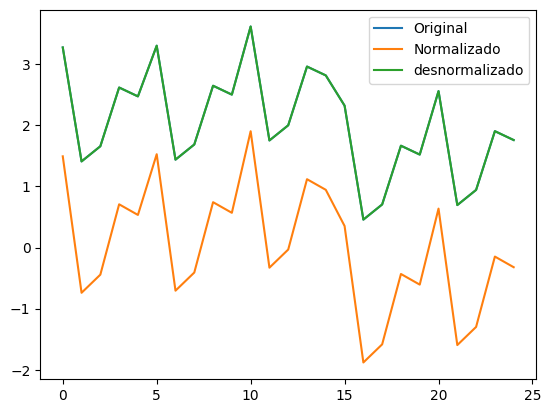

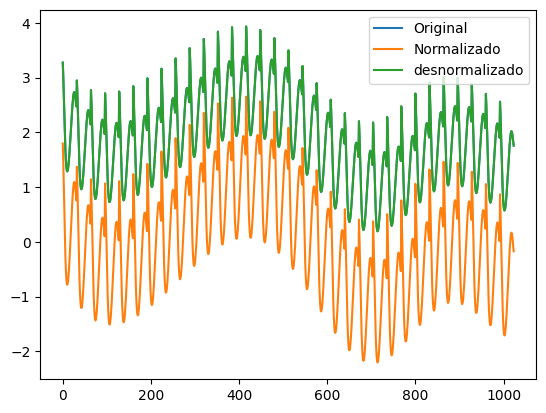

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid):
    x = np.linspace(1, 0, grid)
    y = np.linspace(1, 0, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=mse_loss,
            metrics=['mse']
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=mse_loss
        )
        return self.lm_model


2025-05-25 13:54:18.228247: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [12]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [13]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.5,
            hidden_sizes = [[2,2], [2, 3], [2, 4], [2, 5], [2, 6],[3, 1]],
            regularizers=[0.2, 0.05],
            learning_rate=[0.01, 0.1])

Testando combinacao1: Hidden Size=[2, 2], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_19,0.724378,0.465970,0.537380,-0.255544,0.524018,0.163621,0.317023,0.090876,0.115603,0.103239,0.284389,0.404501,0.265009,0.421721,33.620406,51.903543
model_1_0_18,0.714629,0.460398,0.547617,-0.357474,0.507019,0.169408,0.320331,0.088865,0.124988,0.106926,0.290165,0.411593,0.239011,0.429115,33.550886,51.834023
model_1_0_16,0.688715,0.460036,0.555987,-0.722715,0.433286,0.184792,0.320546,0.087221,0.158617,0.122919,0.295060,0.429875,0.169906,0.448175,33.377045,51.660182
model_1_0_17,0.699709,0.439260,0.572055,-0.626679,0.460946,0.178266,0.332880,0.084065,0.149774,0.116919,0.297455,0.422215,0.199224,0.440190,33.448960,51.732097
model_1_0_15,0.606122,0.434331,0.493241,-1.581735,0.222544,0.233823,0.335805,0.099547,0.237710,0.168628,0.292442,0.483553,-0.050342,0.504138,32.906381,51.189518
model_1_0_14,0.601347,0.431766,0.490948,-1.606520,0.216245,0.236658,0.337328,0.099997,0.239992,0.169994,0.294003,0.486475,-0.063075,0.507185,32.882281,51.165419
model_1_0_20,0.719544,0.399006,0.588684,-1.529743,0.276800,0.166491,0.356776,0.080798,0.232923,0.156860,0.258220,0.408033,0.252117,0.425404,33.585630,51.868767
model_1_0_21,0.714682,0.393131,0.553903,-1.809582,0.201653,0.169377,0.360264,0.087630,0.258689,0.173160,0.249694,0.411554,0.239153,0.429075,33.551258,51.834396
model_1_0_10,0.459945,0.374715,0.314358,-0.300533,0.413476,0.320600,0.371196,0.134686,0.119745,0.127216,0.404523,0.566216,-0.440147,0.590321,32.275121,50.558258
model_1_0_11,0.474910,0.364281,0.237987,-0.088272,0.423946,0.311716,0.377390,0.149688,0.100201,0.124945,0.413445,0.558315,-0.400239,0.582084,32.331326,50.614463


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  16
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  65
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  22
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  46
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 9 +++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_0,0.723042,0.397068,-0.007039,0.521835,0.497202,0.164414,0.357926,0.319963,0.207069,0.263516,0.267269,0.405480,0.261446,0.422742,33.610734,51.893871
model_1_1_1,0.701790,0.316896,-0.122331,0.105516,0.290258,0.177030,0.405520,0.356594,0.387356,0.371975,0.268335,0.420749,0.204775,0.438662,33.462872,51.746009
model_1_1_2,0.691379,0.290813,-0.175268,0.015126,0.236869,0.183211,0.421004,0.373413,0.426499,0.399956,0.265927,0.428031,0.177011,0.446253,33.394237,51.677374
model_1_1_3,0.685751,0.273900,-0.176111,-0.108086,0.185710,0.186552,0.431044,0.373681,0.479856,0.426768,0.256163,0.431916,0.162003,0.450304,33.358093,51.641230
model_1_1_4,0.683164,0.272835,-0.194477,-0.118367,0.175895,0.188088,0.431677,0.379516,0.484308,0.431912,0.256168,0.433691,0.155103,0.452154,33.341693,51.624831
model_1_1_6,0.678162,0.267282,-0.200601,-0.179771,0.148671,0.191057,0.434973,0.381462,0.510899,0.446181,0.255637,0.437101,0.141765,0.455709,33.310367,51.593504
model_1_1_5,0.677069,0.262417,-0.220564,-0.156758,0.152127,0.191705,0.437861,0.387805,0.500933,0.444369,0.257087,0.437842,0.138852,0.456482,33.303590,51.586727
model_1_1_10,0.681824,0.262323,-0.175576,-0.209434,0.144001,0.188883,0.437917,0.373511,0.523745,0.448628,0.251268,0.434607,0.151531,0.453109,33.333257,51.616394
model_1_1_8,0.682051,0.262137,-0.168540,-0.210809,0.145566,0.188748,0.438027,0.371276,0.524340,0.447808,0.251969,0.434452,0.152136,0.452947,33.334681,51.617818
model_1_1_9,0.680847,0.260620,-0.173927,-0.218668,0.140686,0.189463,0.438928,0.372987,0.527743,0.450365,0.252219,0.435273,0.148926,0.453804,33.327124,51.610262


DataFrame salvo em content/results/metrics_1_1
+++++++++++ [1_2] | 1 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_2] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 9 ++++++++++

...

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_5_2,0.719413,0.452129,0.289348,-0.118564,0.309059,0.166568,0.325240,0.291743,0.151238,0.221491,0.259062,0.408128,0.251769,0.425503,33.584699,51.867836
model_1_5_3,0.710017,0.450099,0.248626,-0.276269,0.249726,0.172146,0.326445,0.308460,0.172561,0.240511,0.265871,0.414905,0.226713,0.432568,33.518822,51.801959
model_1_5_1,0.726141,0.446166,0.323708,0.005312,0.357184,0.162574,0.328780,0.277637,0.134489,0.206063,0.254984,0.403205,0.269710,0.420370,33.633239,51.916377
model_1_5_4,0.667685,0.348511,0.125943,-1.092613,-0.000991,0.197276,0.386752,0.358826,0.282937,0.320881,0.292380,0.444158,0.113828,0.463067,33.246300,51.529438
model_1_5_5,0.641999,0.212045,0.077808,-1.669259,-0.153422,0.212525,0.467764,0.378586,0.360904,0.369745,0.305968,0.461004,0.045331,0.480630,33.097393,51.380530
model_1_5_6,0.627552,0.014096,0.061753,-2.088973,-0.252216,0.221101,0.585275,0.385177,0.417652,0.401415,0.312277,0.470214,0.006805,0.490232,33.018270,51.301407
model_1_5_7,0.620035,-0.250203,0.060531,-2.402352,-0.319086,0.225563,0.742175,0.385679,0.460023,0.422851,0.314808,0.474935,-0.013239,0.495154,32.978308,51.261445
model_1_5_8,0.617809,-0.582151,0.069141,-2.627389,-0.361031,0.226885,0.939233,0.382144,0.490450,0.436297,0.314814,0.476325,-0.019177,0.496603,32.966622,51.249759
model_1_5_9,0.632106,-0.998400,0.098536,-2.467147,-0.308415,0.218398,1.186337,0.370077,0.468784,0.419430,0.307181,0.467330,0.018950,0.487225,33.042876,51.326014
model_1_5_0,0.725212,-1.414490,0.419472,0.354993,0.492249,0.163126,1.433346,0.238323,0.087210,0.162767,0.251366,0.403889,0.267232,0.421083,33.626465,51.909602


DataFrame salvo em content/results/metrics_1_5
+++++++++++ [1_6] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_6] | 2 ++++++++++++++++++
Stopped at epoch:  9
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_6] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_6] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_6] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_6] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_6] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_6] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_6] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_6_5,0.668182,-2.007333,0.687693,0.164169,0.534448,0.196982,1.785283,0.183244,0.481036,0.332140,0.245357,0.443826,0.115152,0.462721,33.249290,51.532427
model_1_6_6,0.663782,-2.245789,0.679656,0.121597,0.513972,0.199593,1.926840,0.187959,0.505538,0.346748,0.245212,0.446759,0.103419,0.465778,33.222946,51.506083
model_1_6_8,0.626377,-2.327869,0.636571,-0.183670,0.373127,0.221799,1.975567,0.213239,0.681224,0.447232,0.247160,0.470955,0.003671,0.491005,33.011968,51.295105
model_1_6_4,0.676299,-2.331819,0.710558,0.237009,0.573230,0.192163,1.977912,0.169828,0.439116,0.304472,0.245438,0.438364,0.136796,0.457026,33.298821,51.581958
model_1_6_7,0.649152,-2.457175,0.659830,-0.023068,0.447470,0.208279,2.052329,0.199592,0.588795,0.394193,0.246224,0.456376,0.064404,0.475805,33.137756,51.420893
model_1_6_3,0.692890,-2.574370,0.738832,0.341545,0.627021,0.182314,2.121901,0.153238,0.378953,0.266096,0.244377,0.426982,0.181039,0.445160,33.404049,51.687187
model_1_6_9,0.576027,-2.620288,0.600883,-0.496946,0.232094,0.251689,2.149159,0.234178,0.861520,0.547849,0.248813,0.501686,-0.130595,0.523044,32.759123,51.042261
model_1_6_10,0.533336,-2.679681,0.578732,-0.782539,0.107793,0.277032,2.184418,0.247176,1.025885,0.636530,0.250604,0.526338,-0.244436,0.548745,32.567247,50.850384
model_1_6_1,0.726728,-2.685112,0.821178,0.717652,0.812583,0.162226,2.187642,0.104923,0.162497,0.133710,0.253603,0.402773,0.271274,0.419920,33.637526,51.920663
model_1_6_11,0.477778,-2.832192,0.557128,-1.148975,-0.048891,0.310013,2.274955,0.259852,1.236775,0.748314,0.253864,0.556788,-0.392592,0.580492,32.342279,50.625417


DataFrame salvo em content/results/metrics_1_6
+++++++++++ [1_7] | 1 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_7] | 2 ++++++++++++++++++
Stopped at epoch:  6
1/1 [==============================] - 0s 13ms/step


KeyboardInterrupt: 